In [1]:
# !pip install ta
# !pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ans
from ta.momentum import RSIIndicator

In [3]:
# initializing stock variable
ticker = "GOOG"

# getting and displaying the data of 11 years of GOOG's stock history
data = yf.download(ticker, start="2014-01-01", end="2025-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2014-01-02,27.517694,27.632154,27.397550,27.575543,73129082
2014-01-03,27.316961,27.611886,27.315231,27.564174,66917888
2014-01-06,27.621527,27.659596,27.352559,27.514978,71037271
2014-01-07,28.154018,28.174538,27.716455,27.811383,102486711
2014-01-08,28.212610,28.363163,28.016323,28.330531,90036218


In [4]:
data.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

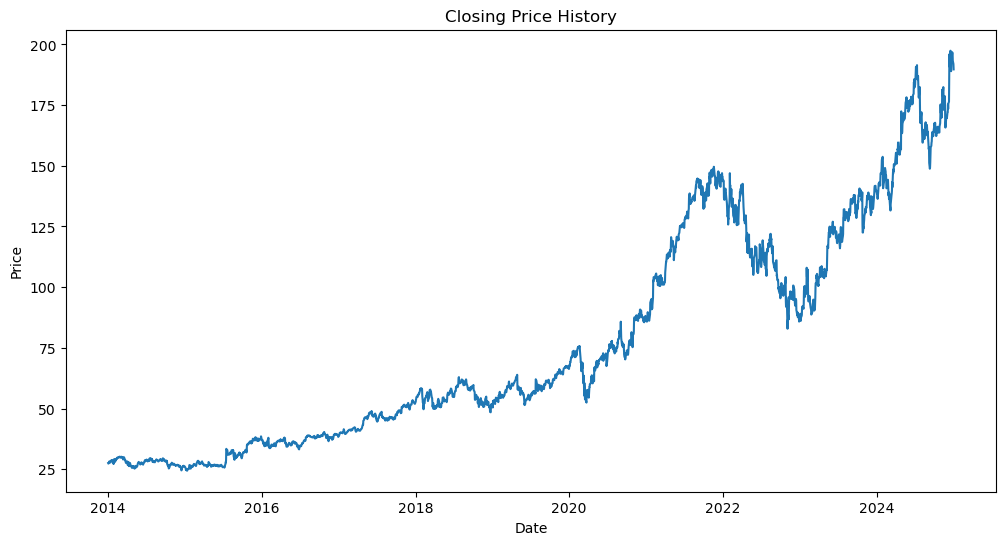

In [5]:
# display the closing price history
plt.figure(figsize=(12,6))

plt.plot(data["Close"])

plt.title("Closing Price History")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

# Creating all the needed variables

In [6]:
# change in close price each day
data["Price_Change"] = data["Close"].diff()

# 20 day moving avg
data["SMA20"] = data["Close"].rolling(window=20).mean()

# 50 day moving avg
data["SMA50"] = data["Close"].rolling(window=50).mean()

# pct change between rows, today and yesterday
data["Daily_Return"] = data["Close"].pct_change()

# standard deviation of last 20 days, higher value = greater volatility
data["Volatility_20"] = data["Daily_Return"].rolling(window=20).std()

# yesterday's price to help predict tomorrow's price
data["Lag1_Close"] = data["Close"].shift(1)

# RSI > 70: overbought
# RSI < 30: oversold
rsi = RSIIndicator(close=data["Close"].squeeze(), window=14)

data["RSI_14"] = rsi.rsi()

# Prediction Targets

In [7]:
# Define target: shift Close price to align today's data with tomorrow's outcome
data["Tomorrow_Close"] = data["Close"].shift(-1)

# Tomorrow > Today: 1 (price went UP)
# Tomorrow <= Today: 0 (price went DOWN)
data["Direction"] = (data["Tomorrow_Close"] > data["Close"].squeeze()).astype(int)

In [8]:
# removing null values, rows contain null values because:
# SMA20 needs 20 days
# SMA50 needs 50 days
# RSI needs 14 days
data = data.dropna()

In [9]:
data.head(10)

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
Date,,,,,,,,,,,,,,
2014-03-14,28.993059,29.439772,28.986384,29.220247,92099924,-0.401968,29.866263,28.937782,-0.013675,0.007145,29.395027,41.274357,29.470179,1
2014-03-17,29.470179,29.593044,29.124329,29.152512,86808163,0.477119,29.853037,28.976832,0.016456,0.008132,28.993059,49.471718,29.943836,1
2014-03-18,29.943836,29.950511,29.493910,29.533712,72872123,0.473658,29.853507,29.029370,0.016072,0.008805,29.470179,56.033085,29.646938,0
2014-03-19,29.646938,29.961887,29.527286,29.957190,64757822,-0.296898,29.849687,29.069878,-0.009915,0.008948,29.943836,51.517234,29.595266,0
2014-03-20,29.595266,29.903045,29.550768,29.664238,67640587,-0.051672,29.841096,29.098703,-0.001743,0.008948,29.646938,50.750633,29.246204,0
2014-03-21,29.246204,29.903544,29.231620,29.821468,128821050,-0.349062,29.815448,29.119375,-0.011795,0.009313,29.595266,45.793273,28.625454,0
2014-03-24,28.625454,29.292185,28.329292,29.274634,121939352,-0.620750,29.747984,29.133065,-0.021225,0.010152,29.246204,38.576668,28.644985,1
2014-03-25,28.644985,28.919886,28.355254,28.824957,96769361,0.019531,29.672238,29.147176,0.000682,0.009985,28.625454,38.902917,27.983694,0


In [10]:
data.describe()

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
count,2718.000000,2718.000000,2718.000000,2718.000000,2.718000e+03,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000
mean,78.071378,78.858382,77.256433,78.026813,3.147159e+07,0.059804,77.505034,76.686182,0.000846,0.016183,78.011574,54.056045,78.130506,0.536424
std,44.897072,45.383439,44.417028,44.868964,1.628444e+07,1.645130,44.389548,43.797690,0.017650,0.007249,44.853574,11.362593,44.938218,0.498763
min,24.377235,24.546795,24.130270,24.481173,1.584340e+05,-13.349854,25.340448,25.765435,-0.111008,0.002915,24.377235,24.077232,24.377235,0.000000
25%,38.963518,39.194787,38.731632,38.895899,2.145550e+07,-0.419724,38.670998,38.612247,-0.007243,0.010847,38.952851,45.776770,38.981009,0.000000
50%,59.863264,60.360287,59.406319,59.801972,2.745900e+07,0.058315,59.630921,59.377033,0.001063,0.014719,59.849121,54.137865,59.891800,1.000000
75%,116.074425,117.370940,114.348126,115.810770,3.630150e+07,0.619237,115.024176,113.553737,0.009440,0.019972,116.022324,62.441607,116.126898,1.000000
max,197.391556,202.093248,195.927250,197.760111,2.232980e+08,15.622803,187.406953,179.180168,0.160524,0.055626,197.391556,89.071401,197.391556,1.000000


In [11]:
data.columns

MultiIndex([(         'Close', 'GOOG'),
            (          'High', 'GOOG'),
            (           'Low', 'GOOG'),
            (          'Open', 'GOOG'),
            (        'Volume', 'GOOG'),
            (  'Price_Change',     ''),
            (         'SMA20',     ''),
            (         'SMA50',     ''),
            (  'Daily_Return',     ''),
            ( 'Volatility_20',     ''),
            (    'Lag1_Close',     ''),
            (        'RSI_14',     ''),
            ('Tomorrow_Close',     ''),
            (     'Direction',     '')],
           names=['Price', 'Ticker'])